# 复用 `vaep/` 准备流程和调参后的 HGB 做 VAEP 实验

这个 notebook 是 `enriched_vaep_features_competition_events.ipynb` 的 tuned-model 副本，原 notebook 保持不变。

核心问题不变：

> 用男足数据训练出的 VAEP 模型，和用女足数据训练出的 VAEP 模型，当它们被用在同一份 held-out 女足 test actions 上时，给出的球员价值和排名有什么差异？

和原版相比，这一版有三个变化：

1. 复用 `vaep/vaep_data.py` 做 data loading & preparation，包括 cache/no-cache 处理、进攻方向 left-to-right 对齐、match-level women final test 预留。
2. 复用 `vaep/hist_gradient_boosting_tuning_results/vaep_training_results.json` 中 grid search 选出的 hyperparameters。
3. 像 xG / xA notebook 一样，用表现最好的 `men_full` hyperparameters 在 notebook 内重新训练 fresh models：`men_downsampled` 和 `women`。

主比较仍然是 `men_downsampled` vs `women`，避免把男足 full sample size 优势混入 gender-domain 比较。

窗口定义也和 tuning 脚本一致：

- 往前看 `3` 个 actions：每一行 feature 使用当前 action 加之前的 game states。
- 往后看 `10` 个 actions：`scores` / `concedes` label 表示当前 action 后 10 个 actions 内是否进球 / 丢球。


## 0. VAEP 在这里到底评价什么？

xG 主要评价 shot quality；xT 主要评价 pass/dribble 是否把球推进到更危险的位置。

VAEP 更细：它试图评价每一个 action 对未来进球和丢球风险的影响。

在 socceraction 的标准 VAEP 框架里，模型先学习两个概率：

- P(score)：当前 game state 下，控球方接下来若干个 actions 内进球的概率。
- P(concede)：当前 game state 下，控球方接下来若干个 actions 内丢球的概率。

然后 VAEP value 看的是 action 前后这些概率的变化：

- offensive value：这个 action 是否提高了后续进球概率。
- defensive value：这个 action 是否降低了后续丢球概率。
- vaep value = offensive value + defensive value。

原 three-method notebook 里把 VAEP 写得很紧凑。这一版会把 feature generation、model training、prediction、VAEP value、player aggregation 拆开写。

## 1. Imports 和 constants

这里不在 notebook 里安装依赖。依赖应该装在项目 `.venv` 里。

注意：当前环境是 NumPy 2.x，而 socceraction / pandera 依赖链比较旧，所以保留一小段 NumPy compatibility aliases，作用只是让 socceraction 能正常 import，不属于 VAEP 逻辑。


In [1]:
import warnings
from pathlib import Path
import json
import sys

print("[setup] stdlib imported", flush=True)

import numpy as np

# Compatibility aliases needed by socceraction/pandera on NumPy 2.x.
if not hasattr(np, "string_"):
    np.string_ = np.bytes_
if not hasattr(np, "float_"):
    np.float_ = np.float64
if not hasattr(np, "complex_"):
    np.complex_ = np.complex128

print("[setup] numpy compatibility ready", flush=True)

import pandas as pd
print("[setup] pandas imported", flush=True)

import matplotlib.pyplot as plt
print("[setup] matplotlib imported", flush=True)

from scipy import stats
from sklearn.base import clone
print("[setup] scipy/sklearn basics imported", flush=True)

warnings.filterwarnings("ignore", category=FutureWarning)
_CHAINED_ASSIGNMENT_ERROR = getattr(pd.errors, "ChainedAssignmentError", None)
if _CHAINED_ASSIGNMENT_ERROR is not None:
    warnings.filterwarnings("ignore", category=_CHAINED_ASSIGNMENT_ERROR)

PROJECT_ROOT = Path.cwd()
VAEP_CODE_DIR = PROJECT_ROOT / "vaep"
if not (VAEP_CODE_DIR / "vaep_data.py").exists():
    raise FileNotFoundError(f"Could not find vaep_data.py under {VAEP_CODE_DIR}. Is the notebook running from the project root?")
VAEP_CODE_DIR = VAEP_CODE_DIR.resolve()
if str(VAEP_CODE_DIR) not in sys.path:
    sys.path.insert(0, str(VAEP_CODE_DIR))
print(f"[setup] using VAEP code dir: {VAEP_CODE_DIR}", flush=True)

# If this cell is rerun after a failed/stale import, force Python to reload the local vaep/ modules.
for module_name in ["vaep_data", "model_contract", "hist_gradient_boosting_model"]:
    module = sys.modules.get(module_name)
    module_file = getattr(module, "__file__", None) if module is not None else None
    if module is not None and (module_file is None or VAEP_CODE_DIR not in Path(module_file).resolve().parents):
        sys.modules.pop(module_name, None)
        print(f"[setup] removed stale module: {module_name}", flush=True)

from vaep_data import (  # noqa: E402
    MEN_COMPETITIONS,
    RANDOM_SEED,
    TARGET_COLUMNS,
    WOMEN_COMPETITIONS,
    action_rows_from_frame,
    build_primary_position_map,
    bucket_position as vaep_bucket_position,
    load_position_rows,
    load_vaep_test_and_rest,
)
print("[setup] vaep_data imported", flush=True)

from model_contract import make_feature_frame  # noqa: E402
print("[setup] model_contract imported", flush=True)

import hist_gradient_boosting_model  # noqa: E402
print("[setup] HGB model family imported", flush=True)

DATA_DIR = Path("data")
CACHE_DIR = Path("vaep_data")
DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

MIN_ACTIONS_PER_PLAYER = 100
MIN_ACTIONS_PER_ACTION_TYPE = 500
MIN_PLAYERS_PER_POSITION_BUCKET = 2

RESULTS_DIR = VAEP_CODE_DIR / "hist_gradient_boosting_tuning_results"
TRAINING_RESULTS_PATH = RESULTS_DIR / "vaep_training_results.json"
if not TRAINING_RESULTS_PATH.exists():
    raise FileNotFoundError(
        f"Missing VAEP tuning results: {TRAINING_RESULTS_PATH}. "
        "Run vaep/train_vaep_probability_models.py first."
    )

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("ready", flush=True)


[setup] stdlib imported
[setup] numpy compatibility ready
[setup] pandas imported
[setup] matplotlib imported
[setup] scipy/sklearn basics imported
[setup] using VAEP code dir: C:\Users\victo\OneDrive\Desktop\statsbomb-open-data-experiments\vaep
[setup] vaep_data imported
[setup] model_contract imported
[setup] HGB model family imported
ready


## 2. Competitions

沿用原 three-method notebook 的比赛范围，保证和 xG / xT / 原 VAEP 分析的研究对象一致。


In [2]:
competition_tables = {
    "women": pd.DataFrame(WOMEN_COMPETITIONS),
    "men": pd.DataFrame(MEN_COMPETITIONS),
}

display(competition_tables["women"])
display(competition_tables["men"])


,competition_id,season_id,league
0,37,281,WSL
1,135,281,Frauen Bundesliga
2,182,281,Liga F
3,131,281,Serie A Women
4,49,107,NWSL


,competition_id,season_id,league
0,11,27,La Liga
1,2,27,Premier League
2,12,27,Serie A
3,7,27,Ligue 1


## 3. 使用 `vaep_data` 加载 prepared VAEP rows

VAEP 需要完整 action sequence，而不是只看 shots 或 passes。这一版不再在 notebook 里直接转换 SPADL 或生成 features，而是复用 `vaep/` 目录里的稳定数据接口。

`load_vaep_test_and_rest()` 会保证：

- cache hit 和 no-cache 都能处理。
- SPADL actions 的进攻方向统一为 left-to-right。
- 女足 final test set 在 data loading 阶段按 match-level 提前预留。
- hyperparameter search 和 notebook 内训练只使用非 test matches。

窗口定义：

- 往前看 `3` 个 actions 来构造 VAEP feature states。
- 往后看 `10` 个 actions 来构造 `scores` / `concedes` labels。


In [3]:
bundle = load_vaep_test_and_rest()

men_vaep_rows = bundle.men_full.copy()
women_train_vaep_rows = bundle.women_train.copy()
women_test_vaep_rows = bundle.women_test.copy()
women_vaep_rows = pd.concat([women_train_vaep_rows, women_test_vaep_rows], ignore_index=True)

split_summary = pd.DataFrame(bundle.split_summary).T

print("target columns:", bundle.target_columns)
print("feature columns:", len(bundle.feature_columns))
print("women test games:", len(bundle.women_test_games))
display(split_summary)


[cache] women VAEP rows: women_vaep_rows_ltr_n3_h10.parquet
[cache] men2015 VAEP rows: men2015_vaep_rows_ltr_n3_h10.parquet
target columns: ('scores', 'concedes')
feature columns: 142
women test games: 231


,rows,games,scores_positives,scores_prevalence,concedes_positives,concedes_prevalence
men_full,3039003.0,1517.0,32077.0,0.010555,6601.0,0.002172
women_train,1058678.0,540.0,13162.0,0.012432,2997.0,0.002831
women_final_test,446416.0,231.0,5462.0,0.012235,1303.0,0.002919


## 4. 共享女足 test games、位置表和门将过滤

和 xG / xT / 原 VAEP 一样，最终比较必须发生在同一批 held-out 女足比赛上。

训练 VAEP 模型时不删门将，因为门将动作是 possession sequence 的一部分。最终做球员排名比较时再过滤门将。


In [4]:
WOMEN_TEST_GAMES = set(bundle.women_test_games)
women_game_ids = np.sort(women_vaep_rows["game_id"].unique())
women_train_actions = women_train_vaep_rows.copy()
women_test_actions = women_test_vaep_rows.copy()

women_position_rows = load_position_rows(CACHE_DIR, "women")
position_map = build_primary_position_map(women_position_rows)


def primary_position_from_key(player_id_key):
    if pd.isna(player_id_key):
        return "Unknown"
    return position_map.get(int(player_id_key), "Unknown")


def is_goalkeeper_key(player_id_key):
    return "Goalkeeper" in str(primary_position_from_key(player_id_key))


def bucket_position(position_name):
    return vaep_bucket_position(position_name)


print("women test games:", len(WOMEN_TEST_GAMES), "of", len(women_game_ids))
print("women train actions:", f"{len(women_train_actions):,}")
print("women test actions:", f"{len(women_test_actions):,}")
print("positions mapped:", len(position_map))
print("goalkeepers:", sum("Goalkeeper" in str(position) for position in position_map.values()))


women test games: 231 of 771
women train actions: 1,058,678
women test actions: 446,416
positions mapped: 1533
goalkeepers: 138


## 5. VAEP features 和 labels

这里直接使用 `vaep_data` 已准备好的 action-level rows。每一行包含：

- metadata / SPADL action columns；
- `scores` 和 `concedes` labels；
- socceraction VAEP feature columns。

feature window 和 label horizon 与 tuning 脚本一致：

- 往前看 `3` 个 actions：`N_PREVIOUS_ACTIONS = 3`，每一行 feature 会使用当前 action 和之前的 game states。
- 往后看 `10` 个 actions：`VAEP_LABEL_HORIZON = 10`，label 表示当前 action 之后 10 个 actions 内控球方是否会进球 / 丢球。

重要：不能在生成 VAEP features / labels 之前先下采样，否则会打断同一场比赛内的前后 action 关系。这个 notebook 中的下采样发生在 `vaep_data` 已经按完整 match sequence 生成 features / labels 之后。`make_feature_frame` 只是从 prepared rows 中取出已有的 feature columns，不是重新计算 VAEP sequence features。

所以每一行对应一个 action 的 game state；模型学习的是：在这个 state 下，未来 10 个 actions 内控球方是否会进球、是否会丢球。


In [5]:
feature_columns = bundle.feature_columns
metadata_columns = [
    "dataset",
    "game_id",
    "action_id",
    "player_id",
    "player_id_key",
    "team_id",
    "type_name",
    "result_name",
    "start_x",
    "start_y",
    "end_x",
    "end_y",
]
metadata_columns = [column for column in metadata_columns if column in women_test_vaep_rows.columns]

# 重要：`men_vaep_rows` 已经是 prepared VAEP rows。
# `vaep_data` 已经先在完整 match sequence 上生成了 features / labels。
# 这里才做 row-level downsample；`make_feature_frame` 只是取出已有的 feature columns。
men_downsample_size = len(women_train_vaep_rows)
if len(men_vaep_rows) < men_downsample_size:
    raise ValueError("Men VAEP sample is smaller than women train sample; cannot downsample as planned.")

men_downsampled_vaep_rows = men_vaep_rows.sample(
    n=men_downsample_size,
    random_state=RANDOM_SEED,
    replace=False,
).reset_index(drop=True)

men_downsampled_features = make_feature_frame(men_downsampled_vaep_rows, feature_columns)
women_train_features = make_feature_frame(women_train_vaep_rows, feature_columns)
women_test_features = make_feature_frame(women_test_vaep_rows, feature_columns)

men_downsampled_labels = men_downsampled_vaep_rows.loc[:, list(TARGET_COLUMNS)].astype(int).reset_index(drop=True)
women_train_labels = women_train_vaep_rows.loc[:, list(TARGET_COLUMNS)].astype(int).reset_index(drop=True)
women_test_labels = women_test_vaep_rows.loc[:, list(TARGET_COLUMNS)].astype(int).reset_index(drop=True)

women_test_action_rows = action_rows_from_frame(women_test_vaep_rows).reset_index(drop=True)
women_test_metadata = women_test_vaep_rows.loc[:, metadata_columns].reset_index(drop=True)

print("feature shapes:")
print("- men downsampled:", men_downsampled_features.shape)
print("- women train:", women_train_features.shape)
print("- women test:", women_test_features.shape)
print("label positive rates:")
print("- men full scores/concedes:", men_vaep_rows.loc[:, list(TARGET_COLUMNS)].mean().round(4).to_dict())
print("- men downsampled scores/concedes:", men_downsampled_labels[list(TARGET_COLUMNS)].mean().round(4).to_dict())
print("- women train scores/concedes:", women_train_labels[list(TARGET_COLUMNS)].mean().round(4).to_dict())
print("- women test scores/concedes:", women_test_labels[list(TARGET_COLUMNS)].mean().round(4).to_dict())


feature shapes:
- men downsampled: (1058678, 142)
- women train: (1058678, 142)
- women test: (446416, 142)
label positive rates:
- men full scores/concedes: {'scores': 0.0106, 'concedes': 0.0022}
- men downsampled scores/concedes: {'scores': 0.0105, 'concedes': 0.0021}
- women train scores/concedes: {'scores': 0.0124, 'concedes': 0.0028}
- women test scores/concedes: {'scores': 0.0122, 'concedes': 0.0029}


## 6. 使用 men-full tuned hyperparameters 训练 VAEP probability models

VAEP 需要两个概率模型：

- `scores` model：预测当前 state 下控球方接下来是否会进球。
- `concedes` model：预测当前 state 下控球方接下来是否会丢球。

这一版像 xG / xA notebook 一样，不直接加载 tuning 脚本保存的 fitted models，而是读取 tuning 结果里的最佳 hyperparameters，然后在 notebook 内重新训练 fresh models。

主比较仍训练两组模型：

- `men_downsampled`：从已经完成 VAEP feature / label 构造的男足 prepared rows 中下采样，规模对齐女足 train。
- `women`：女足 train games。

这里的下采样不会破坏 VAEP 前后 action 关系，因为每行的 features 和 labels 已经在完整比赛序列上预先算好了。

两组模型都使用 grid search 中 `men_full` 表现最好的 hyperparameters；`scores` 和 `concedes` 分别使用各自的 men-full best params。

窗口再次说明：feature 往前看 `3` 个 actions，label 往后看 `10` 个 actions。


In [6]:
training_results = json.loads(TRAINING_RESULTS_PATH.read_text(encoding="utf-8"))
MODEL_FAMILY = "hist_gradient_boosting"

BEST_MEN_FULL_VAEP_PARAMS = {
    target: training_results["selected_candidates"][MODEL_FAMILY][target]["men_full"]["best_params"]
    for target in TARGET_COLUMNS
}

best_params_table = pd.DataFrame(BEST_MEN_FULL_VAEP_PARAMS)
display(best_params_table)

hgb_spec = hist_gradient_boosting_model.get_model_spec(quick=False)


def train_vaep_probability_models(features, labels, model_label):
    """Train scores and concedes classifiers with tuned men-full HGB hyperparameters."""
    models = {}
    for target in TARGET_COLUMNS:
        model = clone(hgb_spec.estimator).set_params(**BEST_MEN_FULL_VAEP_PARAMS[target])
        model.fit(features, labels[target].astype(int))
        models[target] = model
        print(
            f"[trained] {model_label} {target}: "
            f"rows={len(features):,} positives={int(labels[target].sum()):,}"
        )
    return models


def predict_scores_and_concedes(models, features):
    """Predict P(scores) and P(concedes) for a feature matrix."""
    return (
        np.clip(models["scores"].predict_proba(features)[:, 1], 0.0, 1.0),
        np.clip(models["concedes"].predict_proba(features)[:, 1], 0.0, 1.0),
    )


men_downsampled_vaep_models = train_vaep_probability_models(
    men_downsampled_features,
    men_downsampled_labels,
    "men downsampled tuned HGB",
)
women_vaep_models = train_vaep_probability_models(
    women_train_features,
    women_train_labels,
    "women tuned HGB",
)

print("Training action counts:")
print(f"- men full available: {len(men_vaep_rows):,}")
print(f"- men downsampled: {len(men_downsampled_features):,}")
print(f"- women train: {len(women_train_features):,}")
print(f"- women test: {len(women_test_features):,}")


,scores,concedes
model__l2_regularization,0.50,0.100
model__learning_rate,0.02,0.025
model__max_iter,650.00,550.000
model__max_leaf_nodes,63.00,31.000
model__min_samples_leaf,35.00,35.000


[trained] men downsampled tuned HGB scores: rows=1,058,678 positives=11,165
[trained] men downsampled tuned HGB concedes: rows=1,058,678 positives=2,275
[trained] women tuned HGB scores: rows=1,058,678 positives=13,162
[trained] women tuned HGB concedes: rows=1,058,678 positives=2,997
Training action counts:
- men full available: 3,039,003
- men downsampled: 1,058,678
- women train: 1,058,678
- women test: 446,416


## 7. 在同一份女足 test actions 上计算 VAEP value

这一步是核心比较：同一批女足 test actions，分别用男足模型和女足模型预测 P(score) / P(concede)，再用标准 VAEP formula 转成 action value。

VAEP value 会用到上一条 action 的 state value，因此这里按 game 分开计算，避免一场比赛的最后一个 action 意外影响下一场比赛的第一个 action。

主比较使用 tuned `men_downsampled` vs tuned `women`。


In [7]:
from socceraction.vaep import formula as vaep_formula


def calculate_vaep_values_by_game(action_rows, score_probability, concede_probability):
    """Compute standard VAEP values independently within each game."""
    action_rows = action_rows.reset_index(drop=True)
    probabilities = pd.DataFrame(
        {
            "game_id": action_rows["game_id"].values,
            "scores": score_probability,
            "concedes": concede_probability,
        }
    )

    value_frames = []
    for _, game_probabilities in probabilities.groupby("game_id", sort=False):
        row_indices = game_probabilities.index
        game_values = vaep_formula.value(
            action_rows.iloc[row_indices].reset_index(drop=True),
            game_probabilities["scores"].reset_index(drop=True),
            game_probabilities["concedes"].reset_index(drop=True),
        )
        game_values.index = row_indices
        value_frames.append(game_values)

    return pd.concat(value_frames).sort_index().reset_index(drop=True)


def add_model_vaep_values(scored_actions, action_rows, features, models, prefix):
    """Add P(score), P(concede), and standard VAEP value for one model."""
    score_probability, concede_probability = predict_scores_and_concedes(models, features)
    vaep_values = calculate_vaep_values_by_game(action_rows, score_probability, concede_probability)

    scored_actions[f"{prefix}_p_scores"] = score_probability
    scored_actions[f"{prefix}_p_concedes"] = concede_probability
    scored_actions[f"{prefix}_offensive_value"] = vaep_values["offensive_value"].values
    scored_actions[f"{prefix}_defensive_value"] = vaep_values["defensive_value"].values
    scored_actions[f"{prefix}_vaep"] = vaep_values["vaep_value"].values
    return scored_actions


vaep_predictions = women_test_metadata.copy()
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    men_downsampled_vaep_models,
    "men_downsampled",
)
vaep_predictions = add_model_vaep_values(
    vaep_predictions,
    women_test_action_rows,
    women_test_features,
    women_vaep_models,
    "women",
)

vaep_predictions["vaep_delta"] = vaep_predictions["men_downsampled_vaep"] - vaep_predictions["women_vaep"]

print("women test actions scored:", f"{len(vaep_predictions):,}")
display(
    vaep_predictions[
        [
            "game_id",
            "player_id",
            "type_name",
            "result_name",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
        ]
    ].head()
)


women test actions scored: 446,416


,game_id,player_id,type_name,result_name,men_downsampled_vaep,women_vaep,vaep_delta
0,3913167,4638.0,pass,success,0.000000,0.000000,0.000000
1,3913167,46972.0,dribble,success,0.000059,0.000661,-0.000602
2,3913167,46972.0,pass,fail,-0.001072,-0.002616,0.001544
3,3913167,31540.0,pass,success,0.003186,0.004166,-0.000979
4,3913167,31539.0,pass,fail,-0.003860,-0.004940,0.001080


## 8. 球员层面汇总：男足 VAEP vs 女足 VAEP

按球员把 action-level VAEP value 加总，然后比较两个模型下的球员排名。

In [8]:
def spearman_if_available(left, right, min_observations=2):
    """Return Spearman rho only when both inputs have enough non-constant values."""
    paired_values = pd.DataFrame({"left": left, "right": right}).dropna()
    if len(paired_values) < min_observations:
        return np.nan
    if paired_values["left"].nunique() < 2 or paired_values["right"].nunique() < 2:
        return np.nan
    return stats.spearmanr(paired_values["left"], paired_values["right"])[0]


def summarize_player_vaep(scored_actions):
    """Aggregate action-level VAEP values to player-level totals."""
    player_vaep = (
        scored_actions.groupby("player_id")
        .agg(
            player_id_key=("player_id_key", "first"),
            men_downsampled_vaep=("men_downsampled_vaep", "sum"),
            women_vaep=("women_vaep", "sum"),
            action_count=("women_vaep", "size"),
        )
        .reset_index()
    )
    player_vaep["vaep_delta"] = player_vaep["men_downsampled_vaep"] - player_vaep["women_vaep"]
    player_vaep["abs_vaep_delta"] = player_vaep["vaep_delta"].abs()
    return player_vaep


player_vaep_comparison_all = summarize_player_vaep(vaep_predictions)
player_vaep_comparison = player_vaep_comparison_all[
    (player_vaep_comparison_all["action_count"] >= MIN_ACTIONS_PER_PLAYER)
    & (~player_vaep_comparison_all["player_id_key"].map(is_goalkeeper_key))
].copy()

rho_vaep = spearman_if_available(
    player_vaep_comparison["men_downsampled_vaep"],
    player_vaep_comparison["women_vaep"],
)

print(f"VAEP | players={len(player_vaep_comparison)} | Spearman downsampled men vs women={rho_vaep:.3f}")

display(
    player_vaep_comparison.sort_values("abs_vaep_delta", ascending=False)
    .head(20)
    .round(4)
)

VAEP | players=975 | Spearman downsampled men vs women=0.954


,player_id,player_id_key,men_downsampled_vaep,women_vaep,action_count,vaep_delta,abs_vaep_delta
46,5009.0,5009,0.7823,1.8871,424,-1.1048,1.1048
1086,224822.0,224822,3.3260,4.3656,554,-1.0396,1.0396
449,32701.0,32701,1.0817,2.1095,1028,-1.0278,1.0278
302,25466.0,25466,1.5613,2.5710,952,-1.0097,1.0097
992,136433.0,136433,-0.2230,0.7682,589,-0.9911,0.9911
1337,409185.0,409185,1.2499,2.2027,1109,-0.9529,0.9529
630,46987.0,46987,2.2500,1.3231,415,0.9269,0.9269
268,19779.0,19779,0.6843,1.5966,617,-0.9123,0.9123
387,31540.0,31540,1.1284,2.0232,807,-0.8948,0.8948
977,135603.0,135603,0.5493,-0.3202,670,0.8696,0.8696


## 9. 球员 scatter：同一批女足 test actions，不同训练数据模型

如果点贴近对角线，说明男足模型和女足模型对球员总 VAEP 排名/分数接近。偏离越大，说明同一批 actions 被两个模型估值越不同。

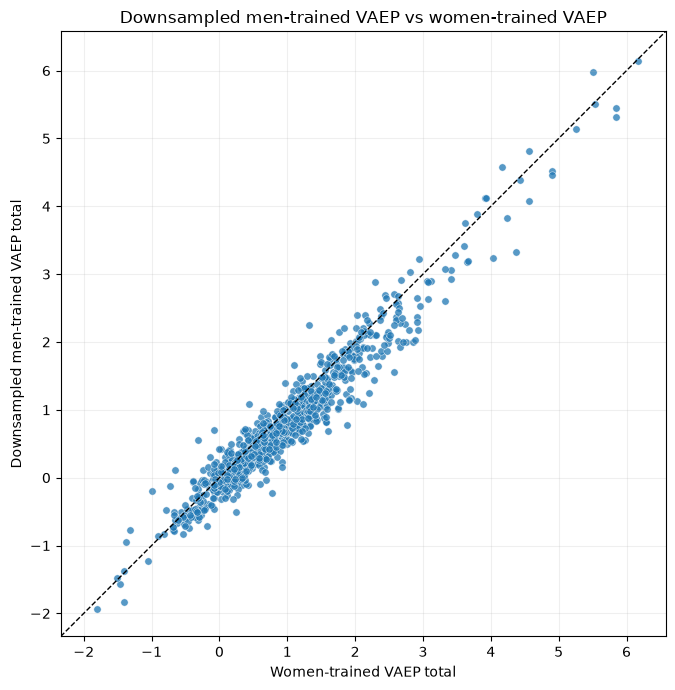

In [9]:
fig, axis = plt.subplots(figsize=(7, 7))

axis.scatter(
    player_vaep_comparison["women_vaep"],
    player_vaep_comparison["men_downsampled_vaep"],
    alpha=0.75,
    s=28,
    edgecolors="white",
    linewidths=0.4,
)
axis_min = min(player_vaep_comparison["women_vaep"].min(), player_vaep_comparison["men_downsampled_vaep"].min())
axis_max = max(player_vaep_comparison["women_vaep"].max(), player_vaep_comparison["men_downsampled_vaep"].max())
padding = (axis_max - axis_min) * 0.05 if axis_max > axis_min else 0.01
axis_min -= padding
axis_max += padding
axis.plot([axis_min, axis_max], [axis_min, axis_max], linestyle="--", color="black", linewidth=1)
axis.set_xlim(axis_min, axis_max)
axis.set_ylim(axis_min, axis_max)
axis.set_aspect("equal", adjustable="box")
axis.set_xlabel("Women-trained VAEP total")
axis.set_ylabel("Downsampled men-trained VAEP total")
axis.set_title("Downsampled men-trained VAEP vs women-trained VAEP")
axis.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## 10. 按 position bucket 分析 VAEP 排名差异

这里把 test-set 球员按主要位置分组，看男足模型和女足模型在不同位置上的排名差异是否不同。

In [10]:
player_vaep_by_position = player_vaep_comparison.copy()
player_vaep_by_position["primary_position"] = player_vaep_by_position["player_id_key"].map(primary_position_from_key)
player_vaep_by_position["position_bucket"] = player_vaep_by_position["primary_position"].map(bucket_position)

player_vaep_by_position["bucket_men_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "men_downsampled_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_women_rank"] = player_vaep_by_position.groupby("position_bucket")[
    "women_vaep"
].rank(ascending=False, method="min")
player_vaep_by_position["bucket_rank_delta"] = (
    player_vaep_by_position["bucket_men_rank"] - player_vaep_by_position["bucket_women_rank"]
)
player_vaep_by_position["abs_bucket_rank_delta"] = player_vaep_by_position["bucket_rank_delta"].abs()

position_rows = []
for position_bucket, bucket_players in player_vaep_by_position.groupby("position_bucket"):
    spearman = spearman_if_available(
        bucket_players["men_downsampled_vaep"],
        bucket_players["women_vaep"],
        min_observations=MIN_PLAYERS_PER_POSITION_BUCKET,
    )

    position_rows.append(
        {
            "position_bucket": position_bucket,
            "players": len(bucket_players),
            "actions": int(bucket_players["action_count"].sum()),
            "spearman_men_vs_women_vaep": spearman,
            "aggregate_vaep_delta": bucket_players["vaep_delta"].sum(),
            "mean_vaep_delta": bucket_players["vaep_delta"].mean(),
            "mean_abs_vaep_delta": bucket_players["abs_vaep_delta"].mean(),
            "mean_bucket_rank_delta": bucket_players["bucket_rank_delta"].mean(),
            "median_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].median(),
            "max_abs_bucket_rank_delta": bucket_players["abs_bucket_rank_delta"].max(),
        }
    )

position_bucket_vaep_summary = (
    pd.DataFrame(position_rows)
    .sort_values(["players", "actions"], ascending=False)
    .reset_index(drop=True)
)

print("Position-bucket VAEP summary:")
display(position_bucket_vaep_summary.round(4))

print()
print("Players with largest within-bucket VAEP rank changes:")
display(
    player_vaep_by_position.sort_values("abs_bucket_rank_delta", ascending=False)[
        [
            "player_id",
            "primary_position",
            "position_bucket",
            "action_count",
            "men_downsampled_vaep",
            "women_vaep",
            "vaep_delta",
            "bucket_men_rank",
            "bucket_women_rank",
            "bucket_rank_delta",
        ]
    ]
    .head(25)
    .round(4)
)

Position-bucket VAEP summary:


,position_bucket,players,actions,spearman_men_vs_women_vaep,aggregate_vaep_delta,mean_vaep_delta,mean_abs_vaep_delta,mean_bucket_rank_delta,median_abs_bucket_rank_delta,max_abs_bucket_rank_delta
0,Fullback / Wing Back,212,95480,0.9527,-39.9056,-0.1882,0.2240,0.0,9.0,81.0
1,Center Back,205,106130,0.9322,-38.3187,-0.1869,0.2364,0.0,10.0,82.0
2,Defensive Midfield,159,66482,0.9609,-24.5432,-0.1544,0.2052,0.0,7.0,56.0
3,Wide Midfielder / Winger,139,46017,0.9629,-12.1054,-0.0871,0.2034,0.0,6.0,39.0
4,Forward,130,36948,0.9620,-2.7944,-0.0215,0.1925,0.0,4.0,51.0
5,Central Midfield,75,30364,0.9472,-12.7564,-0.1701,0.2312,0.0,3.0,33.0
6,Attacking Midfield,55,21537,0.9553,-9.7435,-0.1772,0.2312,0.0,3.0,11.0



Players with largest within-bucket VAEP rank changes:


,player_id,primary_position,position_bucket,action_count,men_downsampled_vaep,women_vaep,vaep_delta,bucket_men_rank,bucket_women_rank,bucket_rank_delta
1255,393574.0,Right Center Back,Center Back,320,0.4257,-0.0093,0.4350,114.0,196.0,-82.0
1128,309391.0,Left Back,Fullback / Wing Back,404,-0.0994,0.6005,-0.6999,202.0,121.0,81.0
588,46559.0,Right Center Back,Center Back,239,0.4173,0.0269,0.3904,116.0,193.0,-77.0
749,50110.0,Right Back,Fullback / Wing Back,451,0.0851,0.6688,-0.5837,186.0,113.0,73.0
723,49995.0,Left Wing Back,Fullback / Wing Back,1002,0.2424,0.7674,-0.5250,160.0,98.0,62.0
695,49898.0,Right Center Back,Center Back,1002,0.1177,0.6229,-0.5053,171.0,113.0,58.0
1336,409184.0,Left Center Back,Center Back,901,0.9816,0.6455,0.3361,53.0,111.0,-58.0
912,106835.0,Right Back,Fullback / Wing Back,577,0.2439,0.7401,-0.4962,159.0,103.0,56.0
995,136441.0,Right Back,Fullback / Wing Back,266,0.5036,0.2838,0.2199,111.0,167.0,-56.0
599,46876.0,Left Defensive Midfield,Defensive Midfield,461,0.3023,-0.1434,0.4457,95.0,151.0,-56.0


## 10.1 Position-bucket visualization

这些图分别看：

- 每个位置 bucket 内，男足 VAEP 和女足 VAEP 的排名相关性。
- 每个位置 bucket 内，player-level VAEP delta 的分布，而不是只看平均值。
- 每个位置 bucket 内，男足 VAEP 排名相对女足 VAEP 排名的移动分布。

右图的横轴是 `player_vaep_delta = men_downsampled_vaep - women_vaep`。每一行是一类位置的球员分布；偏蓝表示该位置 bucket 的 mean delta 更负，偏红表示 mean delta 更正。黑点标出该位置 bucket 的 mean delta。

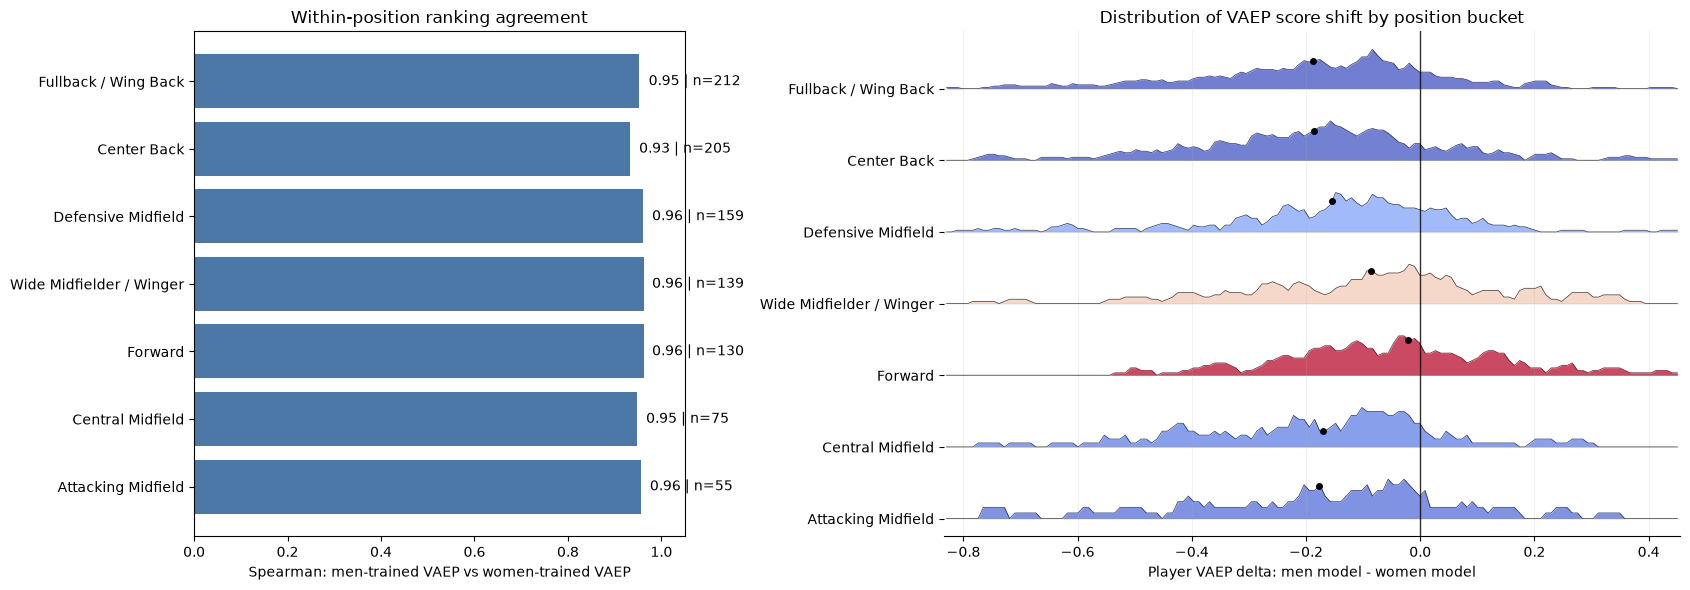

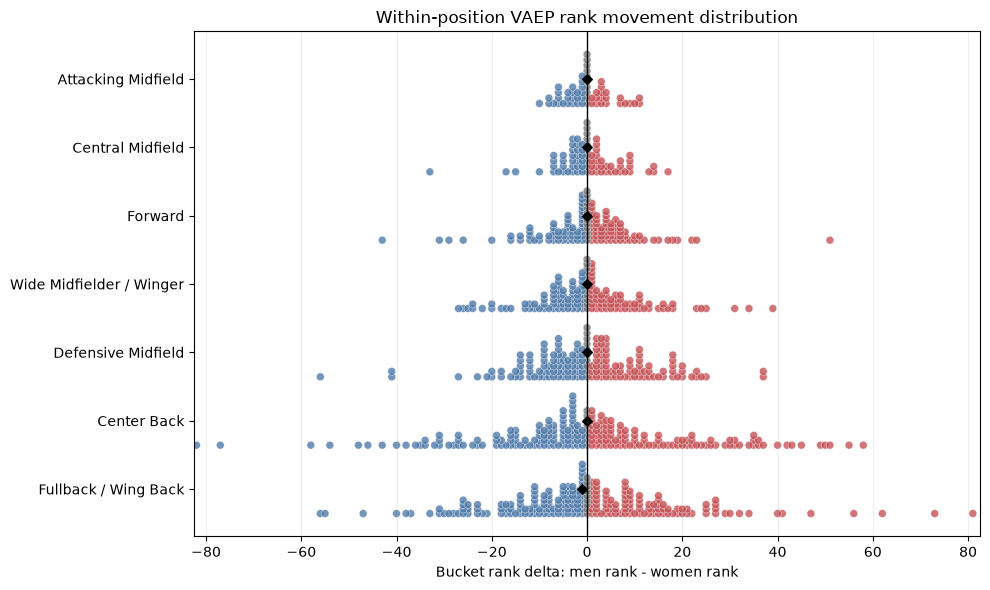

Note: position distributions are smoothed histograms, clipped to the 2%-98% player-delta range for readability. Each ridge is normalized to height 0.55, so shapes are comparable but player counts are shown in the summary table.


In [11]:
plot_position_summary = position_bucket_vaep_summary.sort_values("players", ascending=True)
position_bucket_order = plot_position_summary["position_bucket"].tolist()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.45 * len(position_bucket_order) + 2)),
    gridspec_kw={"width_ratios": [0.9, 1.35]},
)

axes[0].barh(
    plot_position_summary["position_bucket"],
    plot_position_summary["spearman_men_vs_women_vaep"],
    color="#4C78A8",
)
axes[0].set_xlim(0, 1.05)
axes[0].set_xlabel("Spearman: men-trained VAEP vs women-trained VAEP")
axes[0].set_title("Within-position ranking agreement")
for y_index, row in enumerate(plot_position_summary.itertuples(index=False)):
    label = "n=" + str(row.players)
    if pd.notna(row.spearman_men_vs_women_vaep):
        label = f"{row.spearman_men_vs_women_vaep:.2f} | " + label
    axes[0].text(
        0.02 if pd.isna(row.spearman_men_vs_women_vaep) else min(row.spearman_men_vs_women_vaep + 0.02, 0.98),
        y_index,
        label,
        va="center",
    )

POSITION_DISTRIBUTION_BINS = 140
POSITION_DISTRIBUTION_QUANTILES = (0.02, 0.98)
POSITION_SMOOTHING_WINDOW = 5
POSITION_RIDGE_HEIGHT = 0.55
POSITION_ROW_SPACING = 1.0

position_distribution_rows = player_vaep_by_position[
    player_vaep_by_position["position_bucket"].isin(position_bucket_order)
].copy()

x_min, x_max = position_distribution_rows["vaep_delta"].quantile(POSITION_DISTRIBUTION_QUANTILES)
if np.isclose(x_min, x_max):
    x_min -= 0.001
    x_max += 0.001

x_padding = 0.08 * (x_max - x_min)
x_min -= x_padding
x_max += x_padding

bin_edges = np.linspace(x_min, x_max, POSITION_DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(POSITION_SMOOTHING_WINDOW) / POSITION_SMOOTHING_WINDOW

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    plot_position_summary["mean_vaep_delta"].min(),
    plot_position_summary["mean_vaep_delta"].max(),
)
y_positions = np.arange(len(position_bucket_order)) * POSITION_ROW_SPACING

for y_position, position_bucket in zip(y_positions, position_bucket_order):
    values = position_distribution_rows.loc[
        position_distribution_rows["position_bucket"] == position_bucket,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * POSITION_RIDGE_HEIGHT

    summary_row = plot_position_summary[plot_position_summary["position_bucket"] == position_bucket].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axes[1].fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axes[1].plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axes[1].hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axes[1].scatter(mean_delta, y_position + mean_height, color="black", s=16, zorder=4)

axes[1].axvline(0, color="black", linewidth=1.0, alpha=0.8)
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels(position_bucket_order)
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_positions[0] - 0.25, y_positions[-1] + POSITION_RIDGE_HEIGHT + 0.25)
axes[1].set_xlabel("Player VAEP delta: men model - women model")
axes[1].set_title("Distribution of VAEP score shift by position bucket")
axes[1].grid(axis="x", alpha=0.18)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

ordered_buckets = position_bucket_vaep_summary.sort_values("players", ascending=False)["position_bucket"].tolist()
rank_distribution_rows = player_vaep_by_position.dropna(subset=["bucket_rank_delta"]).copy()
RANK_STACK_HEIGHT = 0.72
RANK_STACK_POINT_STEP = 0.09
RANK_STACK_BOTTOM = -RANK_STACK_HEIGHT / 2

fig, axis = plt.subplots(figsize=(10, max(6, 0.55 * len(ordered_buckets) + 2)))
for y_index, position_bucket in enumerate(ordered_buckets):
    bucket_rank_values = rank_distribution_rows.loc[
        rank_distribution_rows["position_bucket"].eq(position_bucket),
        "bucket_rank_delta",
    ].to_numpy()
    if len(bucket_rank_values) == 0:
        continue

    y_offsets = np.zeros_like(bucket_rank_values, dtype=float)
    unique_rank_values, rank_group_ids = np.unique(bucket_rank_values, return_inverse=True)
    max_stack_size = max(np.bincount(rank_group_ids))
    stack_step = min(
        RANK_STACK_POINT_STEP,
        RANK_STACK_HEIGHT / max(max_stack_size - 1, 1),
    )
    for rank_group_id in range(len(unique_rank_values)):
        matching_points = np.flatnonzero(rank_group_ids == rank_group_id)
        y_offsets[matching_points] = RANK_STACK_BOTTOM + np.arange(len(matching_points)) * stack_step

    rank_colors = np.where(
        bucket_rank_values > 0,
        "#C44E52",
        np.where(bucket_rank_values < 0, "#4C78A8", "#777777"),
    )
    axis.scatter(
        bucket_rank_values,
        y_index + y_offsets,
        color=rank_colors,
        alpha=0.78,
        s=32,
        edgecolors="white",
        linewidths=0.35,
    )
    axis.scatter(
        np.median(bucket_rank_values),
        y_index,
        color="black",
        marker="D",
        s=24,
        zorder=4,
    )

rank_limit = rank_distribution_rows["bucket_rank_delta"].abs().max()
if pd.isna(rank_limit) or rank_limit == 0:
    rank_limit = 1
axis.axvline(0, color="black", linewidth=1)
axis.set_xlim(-rank_limit - 0.5, rank_limit + 0.5)
axis.set_yticks(np.arange(len(ordered_buckets)))
axis.set_yticklabels(ordered_buckets)
axis.set_xlabel("Bucket rank delta: men rank - women rank")
axis.set_title("Within-position VAEP rank movement distribution")
axis.grid(axis="x", alpha=0.2)
plt.tight_layout()
plt.show()

print(
    "Note: position distributions are smoothed histograms, clipped to the "
    f"{POSITION_DISTRIBUTION_QUANTILES[0]:.0%}-{POSITION_DISTRIBUTION_QUANTILES[1]:.0%} player-delta range for readability. "
    f"Each ridge is normalized to height {POSITION_RIDGE_HEIGHT}, so shapes are comparable but player counts are shown in the summary table."
)

## 11. Action-type mechanism：哪些动作被男足模型和女足模型估值不同？

VAEP 的优势是能看不同 action type 的差异。这里先按 action type 汇总 action-level VAEP delta，然后不只看 mean，而是把每类动作的 delta distribution 画出来。

图里的横轴是 `vaep_delta = men_downsampled_vaep - women_vaep`。正值表示男足模型给该类女足 test actions 的 VAEP 更高；负值表示女足模型更高。

2D ridgeline 图的读法：每一行是一种 action type 的 delta 分布；隆起越高，说明该 delta 附近的 actions 越多。每一行的颜色表示该 action type 的 mean delta：偏蓝表示女足模型平均给分更高，偏红表示男足模型平均给分更高。黑点标出该类动作的 mean delta。

Action types with at least 500 test actions:


,type_name,actions,aggregate_vaep_delta,mean_vaep_delta,median_vaep_delta,delta_std,mean_men_vaep,mean_women_vaep
2,corner_crossed,1818,-13.338979,-0.007337,-0.006836,0.027685,-0.006275,0.001062
7,freekick_crossed,1854,-9.881762,-0.005330,-0.004005,0.017274,0.014821,0.020151
12,shot,5734,-23.266232,-0.004058,-0.000727,0.047089,0.034305,0.038362
17,throw_in,12037,-18.815528,-0.001563,-0.000984,0.003950,0.002840,0.004404
4,cross,5023,-6.209645,-0.001236,-0.002231,0.030727,0.015887,0.017124
15,tackle,9424,-9.207674,-0.000977,-0.001342,0.011593,0.008806,0.009784
8,freekick_short,2430,-1.880852,-0.000774,-0.000545,0.005096,0.001759,0.002533
16,take_on,7333,-2.934268,-0.000400,0.000534,0.016900,-0.003200,-0.002800
11,pass,170861,-58.922456,-0.000345,-0.000216,0.007500,0.000536,0.000881
10,interception,4939,-0.793864,-0.000161,-0.000386,0.009575,-0.001138,-0.000977


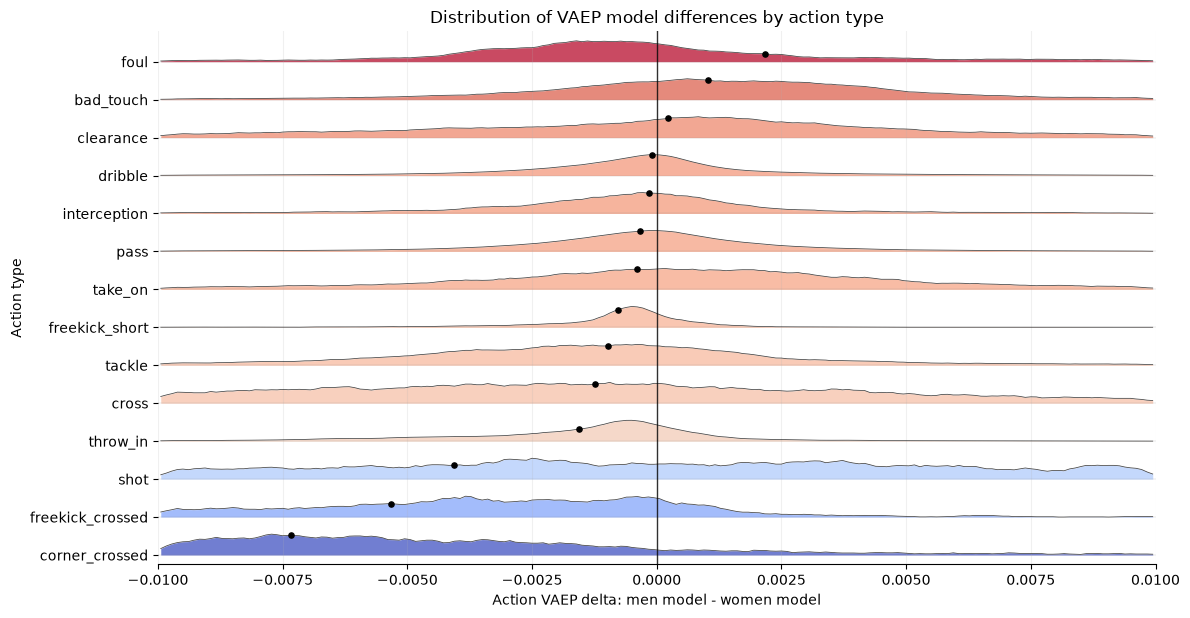

Note: distributions are smoothed histograms shown within [-0.01, +0.01] for readability. Each ridge is normalized to height 0.55, so shapes are comparable but absolute frequencies are shown in the table.


In [12]:
non_goalkeeper_predictions = vaep_predictions[~vaep_predictions["player_id_key"].map(is_goalkeeper_key)].copy()

action_type_vaep_summary = (
    non_goalkeeper_predictions
    .groupby("type_name")
    .agg(
        actions=("vaep_delta", "size"),
        aggregate_vaep_delta=("vaep_delta", "sum"),
        mean_vaep_delta=("vaep_delta", "mean"),
        median_vaep_delta=("vaep_delta", "median"),
        delta_std=("vaep_delta", "std"),
        mean_men_vaep=("men_downsampled_vaep", "mean"),
        mean_women_vaep=("women_vaep", "mean"),
    )
    .reset_index()
)

action_type_vaep_summary = action_type_vaep_summary[
    action_type_vaep_summary["actions"] >= MIN_ACTIONS_PER_ACTION_TYPE
].sort_values("mean_vaep_delta")

print(f"Action types with at least {MIN_ACTIONS_PER_ACTION_TYPE:,} test actions:")
display(action_type_vaep_summary.round(6))

selected_action_types = action_type_vaep_summary["type_name"].tolist()
distribution_rows = non_goalkeeper_predictions[
    non_goalkeeper_predictions["type_name"].isin(selected_action_types)
].copy()

DISTRIBUTION_BINS = 180
SMOOTHING_WINDOW = 7
RIDGE_HEIGHT = 0.55
ROW_SPACING = 1.0
PLOT_DELTA_LIMIT = 0.01

x_min, x_max = -PLOT_DELTA_LIMIT, PLOT_DELTA_LIMIT

bin_edges = np.linspace(x_min, x_max, DISTRIBUTION_BINS + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
smoothing_kernel = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW

fig_height = max(6, 0.32 * len(selected_action_types) + 1.8)
fig, axis = plt.subplots(figsize=(12, fig_height))

cmap = plt.colormaps["coolwarm"]
color_norm = plt.Normalize(
    action_type_vaep_summary["mean_vaep_delta"].min(),
    action_type_vaep_summary["mean_vaep_delta"].max(),
)

y_positions = np.arange(len(selected_action_types)) * ROW_SPACING

for y_position, action_type in zip(y_positions, selected_action_types):
    values = distribution_rows.loc[
        distribution_rows["type_name"] == action_type,
        "vaep_delta",
    ].dropna().to_numpy()

    histogram, _ = np.histogram(values, bins=bin_edges, density=True)
    smoothed_density = np.convolve(histogram, smoothing_kernel, mode="same")
    if smoothed_density.max() > 0:
        smoothed_density = smoothed_density / smoothed_density.max() * RIDGE_HEIGHT

    summary_row = action_type_vaep_summary[action_type_vaep_summary["type_name"] == action_type].iloc[0]
    ridge_color = cmap(color_norm(summary_row["mean_vaep_delta"]))

    axis.fill_between(
        bin_centers,
        y_position,
        y_position + smoothed_density,
        color=ridge_color,
        alpha=0.72,
        linewidth=0,
    )
    axis.plot(
        bin_centers,
        y_position + smoothed_density,
        color="black",
        linewidth=0.55,
        alpha=0.75,
    )
    axis.hlines(y_position, x_min, x_max, color="gray", linewidth=0.35, alpha=0.35)

    mean_delta = values.mean()
    if x_min <= mean_delta <= x_max:
        mean_height = np.interp(mean_delta, bin_centers, smoothed_density)
        axis.scatter(mean_delta, y_position + mean_height, color="black", s=14, zorder=4)

axis.axvline(0, color="black", linewidth=1.0, alpha=0.8)
axis.set_yticks(y_positions)
axis.set_yticklabels(selected_action_types)
axis.set_xlim(x_min, x_max)
axis.set_ylim(y_positions[0] - 0.25, y_positions[-1] + RIDGE_HEIGHT + 0.25)
axis.set_xlabel("Action VAEP delta: men model - women model")
axis.set_ylabel("Action type")
axis.set_title("Distribution of VAEP model differences by action type")
axis.grid(axis="x", alpha=0.18)
axis.spines["top"].set_visible(False)
axis.spines["right"].set_visible(False)
axis.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

print(
    "Note: distributions are smoothed histograms shown within "
    f"[-{PLOT_DELTA_LIMIT:.2f}, +{PLOT_DELTA_LIMIT:.2f}] for readability. "
    f"Each ridge is normalized to height {RIDGE_HEIGHT}, so shapes are comparable but absolute frequencies are shown in the table."
)

## 12. Read-out

这个 notebook 最后应该回答：

1. 男足训练的 VAEP 模型和女足训练的 VAEP 模型，在同一批女足 test actions 上给出的球员排名有多一致？
2. 差异是否集中在某些 position bucket？
3. 差异是否集中在某些 action type？

如果 VAEP 比 xG/xT 显示更低 Spearman 或更明显的位置/action-type 差异，说明更细粒度的 action-value model 捕捉到了 position-only 或 shot-only metric 看不到的迁移差异。